##**Author:** Ameer Hamza
##**Github:** https://github.com/mh25afc/microscopy-nuclei-analysis

In [ ]:
# Clone dataset and inspect structure
!git clone https://github.com/Nickolay-K/Assingnment-3-dataset.git
!find /content/Assingnment-3-dataset -type f | head -50

Cloning into 'Assingnment-3-dataset'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 10.94 MiB | 17.81 MiB/s, done.
/content/Assingnment-3-dataset/nuclei_dataset.zip
/content/Assingnment-3-dataset/.git/info/exclude
/content/Assingnment-3-dataset/.git/index
/content/Assingnment-3-dataset/.git/packed-refs
/content/Assingnment-3-dataset/.git/logs/refs/heads/main
/content/Assingnment-3-dataset/.git/logs/refs/remotes/origin/HEAD
/content/Assingnment-3-dataset/.git/logs/HEAD
/content/Assingnment-3-dataset/.git/config
/content/Assingnment-3-dataset/.git/description
/content/Assingnment-3-dataset/.git/hooks/commit-msg.sample
/content/Assingnment-3-dataset/.git/hooks/pre-receive.sample
/content/Assingnment-3-dataset/.git/hooks/pre-push.sample
/content/Assingnment-3-dataset/.git/hooks/pre-merge-commit.sample
/cont

Dataset unzipped to: /content/Assingnment-3-dataset/nuclei_dataset_extracted
Found 340 images
['/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_000.png', '/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_010.png', '/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_015.png', '/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_014.png', '/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_008.png']
(256, 256) I;16


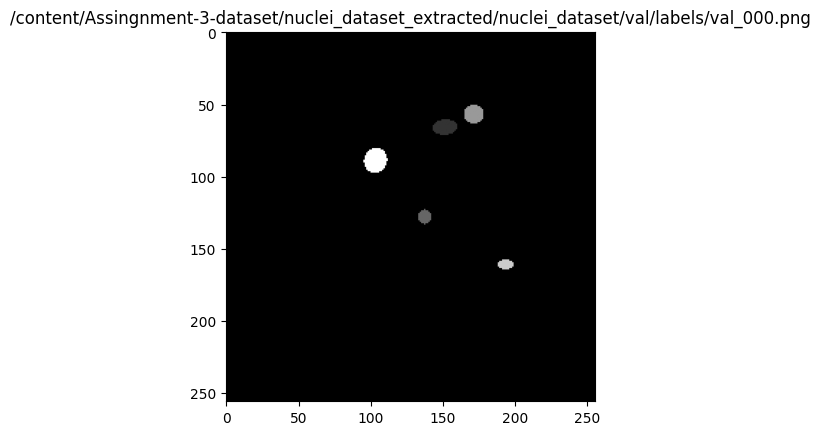

In [ ]:
# Peek at one image
import matplotlib.pyplot as plt
from PIL import Image
import glob
import zipfile
import os

# Unzip the dataset if it hasn't been unzipped
zip_path = '/content/Assingnment-3-dataset/nuclei_dataset.zip'
extract_path = '/content/Assingnment-3-dataset/nuclei_dataset_extracted'

# Check if the extracted directory already exists to avoid re-extraction
if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Dataset unzipped to: {extract_path}")
else:
    print(f"Dataset already unzipped at: {extract_path}")

# Adjust this glob once you see the real folder structure
image_paths = glob.glob(f'{extract_path}/**/*.png', recursive=True) + \
              glob.glob(f'{extract_path}/**/*.jpg', recursive=True)
print(f"Found {len(image_paths)} images")
print(image_paths[:5])

if len(image_paths) > 0:
    img = Image.open(image_paths[0])
    print(img.size, img.mode)
    plt.imshow(img, cmap='gray')
    plt.title(image_paths[0])
    plt.show()
else:
    print("No images found after extraction. Please check the dataset structure within the zip file.")

In [ ]:
import subprocess
print(subprocess.run(['find', '/content/Assingnment-3-dataset', '-type', 'd'], capture_output=True, text=True).stdout)

/content/Assingnment-3-dataset
/content/Assingnment-3-dataset/nuclei_dataset_extracted
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/masks
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/images
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/train
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/train/labels
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/train/masks
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/train/images
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/test
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/test/labels
/content/Assingnment-3-dataset/nucl

In [ ]:
print(subprocess.run(['find', '/content/Assingnment-3-dataset', '-type', 'f'], capture_output=True, text=True).stdout[:3000])

/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/make_dataset.py
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/README.md
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_000.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_010.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_015.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_014.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_008.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_011.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_019.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/labels/val_003.png
/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset/val/label

In [ ]:
from PIL import Image

base = '/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset'

for split in ['train', 'val', 'test', 'test_corrupted']:
    img_dir = os.path.join(base, split, 'images')
    if os.path.exists(img_dir):
        files = sorted(glob.glob(os.path.join(img_dir, '*')))
        print(f"{split}: {len(files)} images")
        if files:
            im = Image.open(files[0])
            print(f"  sample: {os.path.basename(files[0])} size={im.size} mode={im.mode}")

# check if images/masks/labels filenames match for train
img_files = sorted(os.listdir(os.path.join(base, 'train', 'images')))
mask_files = sorted(os.listdir(os.path.join(base, 'train', 'masks')))
label_files = sorted(os.listdir(os.path.join(base, 'train', 'labels')))
print("\nSample filenames:")
print("images:", img_files[:5])
print("masks:", mask_files[:5])
print("labels:", label_files[:5])

train: 80 images
  sample: train_000.png size=(256, 256) mode=RGB
val: 20 images
  sample: val_000.png size=(256, 256) mode=RGB
test: 12 images
  sample: test_000.png size=(256, 256) mode=RGB
test_corrupted: 4 images
  sample: test_000_blur.png size=(256, 256) mode=RGB

Sample filenames:
images: ['train_000.png', 'train_001.png', 'train_002.png', 'train_003.png', 'train_004.png']
masks: ['train_000.png', 'train_001.png', 'train_002.png', 'train_003.png', 'train_004.png']
labels: ['train_000.png', 'train_001.png', 'train_002.png', 'train_003.png', 'train_004.png']


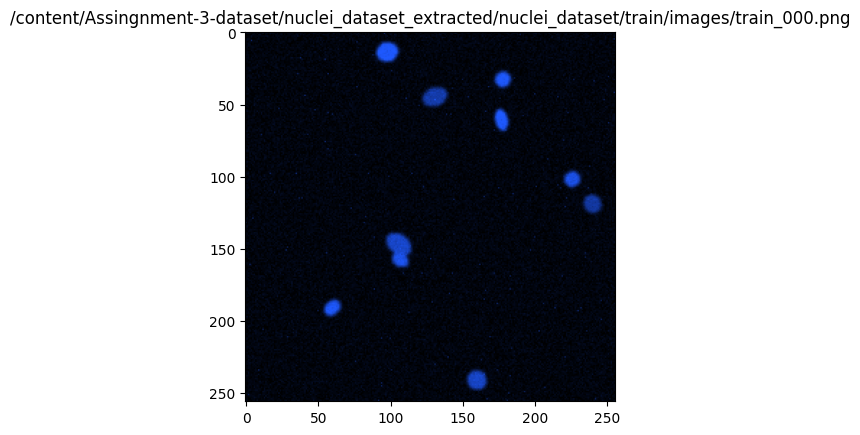

(256, 256) RGB


In [ ]:
img_path = os.path.join(base, 'train', 'images', img_files[0])
im = Image.open(img_path)
plt.imshow(im, cmap='gray' if im.mode == 'L' else None)
plt.title(img_path)
plt.show()
print(im.size, im.mode)

### Install Ollama in Colab and pull the vision model

In [ ]:
!pip install -q ollama

In [ ]:
!apt-get update && apt-get install -y zstd

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [107 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,908 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,199 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-d

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
!ollama serve > /tmp/ollama.log 2>&1 &

In [ ]:
!sleep 5

In [ ]:
!ollama pull llava

### Step 2: Grayscale + resize + EDA

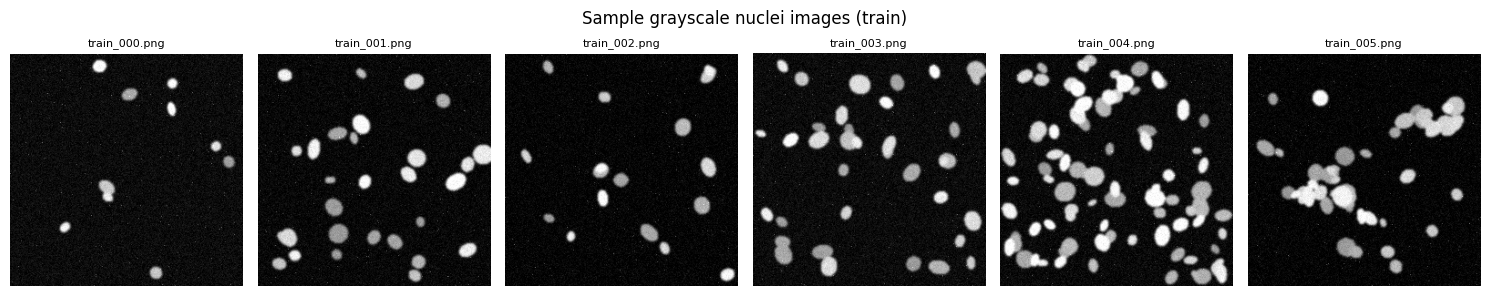

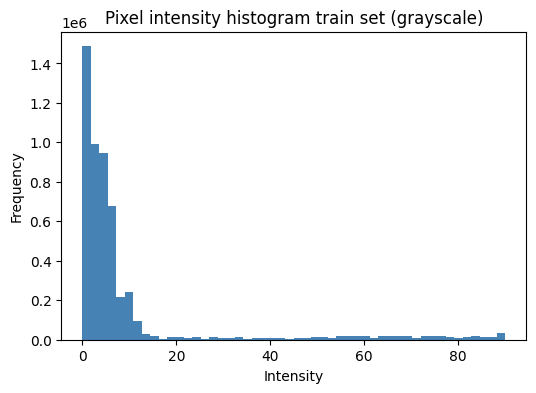

Train images: 80
Pixel intensity range: 0 - 90, mean=9.3


In [ ]:
import numpy as np


base = '/content/Assingnment-3-dataset/nuclei_dataset_extracted/nuclei_dataset'
OUT_SIZE = (256, 256)

def load_grayscale_resized(path):
    im = Image.open(path).convert('L')      # grayscale
    im = im.resize(OUT_SIZE)                 # resize (no-op here, but explicit)
    return np.array(im)

# Load a few train images for EDA
train_img_dir = os.path.join(base, 'train', 'images')
train_files = sorted(glob.glob(os.path.join(train_img_dir, '*.png')))

sample_imgs = [load_grayscale_resized(p) for p in train_files[:6]]

# EDA: sample grid
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, im, path in zip(axes, sample_imgs, train_files[:6]):
    ax.imshow(im, cmap='gray')
    ax.set_title(os.path.basename(path), fontsize=8)
    ax.axis('off')
plt.suptitle("Sample grayscale nuclei images (train)")
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150)
plt.show()

# EDA: intensity histogram (across all train images)
all_pixels = np.concatenate([load_grayscale_resized(p).ravel() for p in train_files])
plt.figure(figsize=(6,4))
plt.hist(all_pixels, bins=50, color='steelblue')
plt.title("Pixel intensity histogram train set (grayscale)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.savefig('eda_histogram.png', dpi=150)
plt.show()

print(f"Train images: {len(train_files)}")
print(f"Pixel intensity range: {all_pixels.min()} - {all_pixels.max()}, mean={all_pixels.mean():.1f}")

### Send one image to the VLM: naive vs. optimised prompt

In [ ]:
import base64, json
import ollama

def image_to_base64(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

representative_image = train_files[0]
img_b64 = image_to_base64(representative_image)

# Naive prompt
naive_prompt = "What do you see in this image?"

naive_response = ollama.chat(
    model='llava',
    messages=[{
        'role': 'user',
        'content': naive_prompt,
        'images': [img_b64]
    }]
)
print("=== NAIVE PROMPT OUTPUT ===")
print(naive_response['message']['content'])

=== NAIVE PROMPT OUTPUT ===
 The image appears to show a night sky background with a pattern of circular or spherical shapes, which could be interpreted as stars, planets, or some sort of celestial objects. However, upon closer inspection, these shapes resemble small dots or particles, which are most likely artificial in nature, such as a digital display or a graphical representation. The dots are scattered throughout the image, creating a star-like effect. The background suggests it is taken from a vantage point at night. 


In [ ]:
optimised_prompt = """You are an image description assistant helping catalogue microscopy images for research purposes. You are NOT a diagnostic tool and must not provide any clinical or diagnostic interpretation.

Describe ONLY what is visually observable in this fluorescence microscopy image. Do not guess at disease state, patient information, or clinical significance.

If you are not confident about any field, respond with "uncertain" for that field rather than guessing.

Respond ONLY with a valid JSON object in exactly this format, with no extra text before or after it:

{
  "modality": "<imaging modality you observe, or 'uncertain'>",
  "tissue_type": "<tissue/cell type you observe, or 'uncertain'>",
  "notable_features": "<brief description of visible structures, staining pattern, distribution, or 'uncertain'>",
  "image_quality": "<brief assessment of focus/contrast/noise, or 'uncertain'>"
}"""

optimised_response = ollama.chat(
    model='llava',
    messages=[{
        'role': 'user',
        'content': optimised_prompt,
        'images': [img_b64]
    }]
)
print("=== OPTIMISED PROMPT OUTPUT (run 1) ===")
print(optimised_response['message']['content'])

=== OPTIMISED PROMPT OUTPUT (run 1) ===
 ```json
{
  "modality": "fluorescence microscopy",
  "tissue_type": "cells",
  "notable_features": "The image displays a pattern of small, spherical, fluorescent objects, likely representing cells. The objects are distributed throughout the field of view, and they are uniformly sized and shaped. The background is dark, providing contrast that highlights the objects. The focus and contrast appear high, suggesting a clear image of the cells.",
  "image_quality": "good"
}
``` 


### Show non-determinism

In [ ]:
optimised_response_2 = ollama.chat(
    model='llava',
    messages=[{
        'role': 'user',
        'content': optimised_prompt,
        'images': [img_b64]
    }]
)
print("=== OPTIMISED PROMPT OUTPUT (run 2) ===")
print(optimised_response_2['message']['content'])

print("\nIdentical outputs?", optimised_response['message']['content'] == optimised_response_2['message']['content'])

=== OPTIMISED PROMPT OUTPUT (run 2) ===
 {
  "modality": "Fluorescence microscopy",
  "tissue_type": "Cell culture",
  "notable_features": "The image is a fluorescence microscopy image, showing a cluster of blue-stained cells against a darker background. The cells are likely adherent cells, and they are round in shape. The staining appears to be uneven, with some cells appearing brighter than others. The distribution of cells is scattered, but they are not uniformly distributed. The quality of the image is somewhat low, with noticeable noise, which could affect the clarity and resolution of the cells. However, the overall focus appears to be adequate.",
  "image_quality": "Adequate"
} 

Identical outputs? False


##**Task 2: classical segmentation and feature extraction**

Number of detected objects: 9


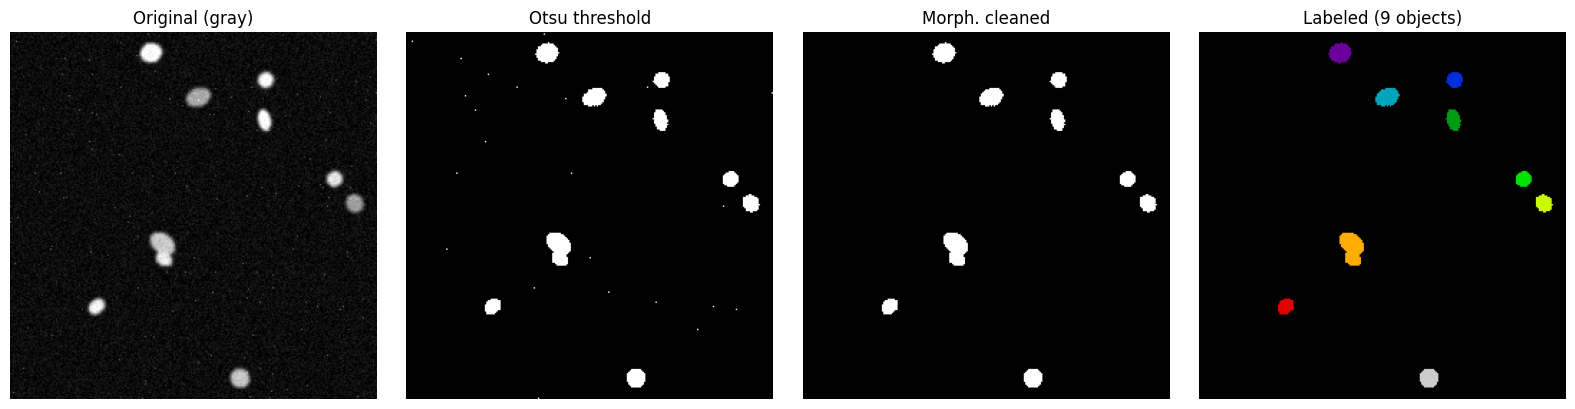

In [ ]:
from skimage import io, filters, morphology, measure

# Use the same representative image as Task 1 for direct comparison
img_path = train_files[0]
img_gray = io.imread(img_path, as_gray=True)

# Otsu thresholding
thresh = filters.threshold_otsu(img_gray)
binary = img_gray > thresh

# Morphological cleanup
binary_clean = morphology.remove_small_objects(binary, min_size=20)
binary_clean = morphology.binary_closing(binary_clean, morphology.disk(2))

# Label connected components
labeled = measure.label(binary_clean)
n_objects = labeled.max()
print(f"Number of detected objects: {n_objects}")

# Visualize pipeline
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title('Original (gray)')
axes[1].imshow(binary, cmap='gray'); axes[1].set_title('Otsu threshold')
axes[2].imshow(binary_clean, cmap='gray'); axes[2].set_title('Morph. cleaned')
axes[3].imshow(labeled, cmap='nipy_spectral'); axes[3].set_title(f'Labeled ({n_objects} objects)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('task2_pipeline.png', dpi=150)
plt.show()

In [ ]:
# regionprops table
props = measure.regionprops_table(
    labeled, intensity_image=img_gray,
    properties=['label', 'area', 'eccentricity', 'solidity', 'mean_intensity', 'perimeter']
)

import pandas as pd
df = pd.DataFrame(props)
print(df)
print("\nSummary stats:")
print(df.describe())

   label   area  eccentricity  solidity  mean_intensity  perimeter
0      1  173.0      0.482627  0.920213        0.297159  48.870058
1      2  100.0      0.130864  0.934579        0.282059  35.556349
2      3  169.0      0.691543  0.944134        0.211206  48.870058
3      4  118.0      0.789353  0.907692        0.284158  41.798990
4      5   98.0      0.331551  0.980000        0.261829  33.556349
5      6  114.0      0.474943  0.919355        0.196633  38.970563
6      7  286.0      0.797204  0.910828        0.260037  67.698485
7      8  100.0      0.609029  0.943396        0.276513  35.313708
8      9  143.0      0.180389  0.986207        0.237050  40.970563

Summary stats:
          label        area  eccentricity  solidity  mean_intensity  perimeter
count  9.000000    9.000000      9.000000  9.000000        9.000000   9.000000
mean   5.000000  144.555556      0.498612  0.938489        0.256294  43.511680
std    2.738613   60.407183      0.247066  0.028472        0.034508  10.61862

In [ ]:
# Build a plain-language numeric summary (NO IMAGE) and send to model
summary_text = f"""Here is a quantitative summary of objects detected in a microscopy image via classical image processing (Otsu thresholding + connected component labeling). No image is provided — base your interpretation only on these numbers.

Number of objects detected: {n_objects}
Mean object area (pixels): {df['area'].mean():.1f}
Area range: {df['area'].min():.0f} - {df['area'].max():.0f}
Mean eccentricity (0=circular, 1=elongated): {df['eccentricity'].mean():.2f}
Mean solidity (compactness, 1=fully convex): {df['solidity'].mean():.2f}
Mean intensity of detected objects: {df['mean_intensity'].mean():.3f}

Based ONLY on these numbers, respond ONLY with a valid JSON object in this exact format, no extra text:

{{
  "n_objects": <integer>,
  "density_class": "<sparse | moderate | dense, or 'uncertain'>",
  "shape_regularity": "<regular | irregular | mixed, based on eccentricity/solidity, or 'uncertain'>",
  "quality_flag": "<any concern about the numbers suggesting noisy/unreliable detection, or 'none'>"
}}"""

numbers_response = ollama.chat(
    model='llava',
    messages=[{'role': 'user', 'content': summary_text}]
)
print("=== NUMBERS-FIRST LLM OUTPUT ===")
print(numbers_response['message']['content'])

=== NUMBERS-FIRST LLM OUTPUT ===
 ```json
{
  "n_objects": 9,
  "density_class": "moderate",
  "shape_regularity": "regular",
  "quality_flag": "none"
}
``` 


##**Task 3: U-Net training**

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        ch = in_ch
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(f*2, f))

        self.final_conv = nn.Conv2d(features[0], out_ch, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)

        return self.final_conv(x)

# quick sanity check
model = UNet(in_ch=3, out_ch=1)
test_input = torch.randn(1, 3, 256, 256)
print("Output shape:", model(test_input).shape)  # should be [1, 1, 256, 256]

Output shape: torch.Size([1, 1, 256, 256])


### Dataset class

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class NucleiDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=256):
        self.img_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))
        self.mask_dir = mask_dir
        self.size = size
        self.img_transform = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),  # scales to [0,1]
        ])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        fname = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_dir, fname)

        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L').resize((self.size, self.size))

        img = self.img_transform(img)
        mask = np.array(mask)
        mask = (mask > 127).astype(np.float32)  # binarize
        mask = torch.from_numpy(mask).unsqueeze(0)  # add channel dim

        return img, mask

train_ds = NucleiDataset(
    os.path.join(base, 'train', 'images'),
    os.path.join(base, 'train', 'masks')
)
val_ds = NucleiDataset(
    os.path.join(base, 'val', 'images'),
    os.path.join(base, 'val', 'masks')
)
test_ds = NucleiDataset(
    os.path.join(base, 'test', 'images'),
    os.path.join(base, 'test', 'masks')
)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# sanity check one batch
imgs, masks = next(iter(train_loader))
print(imgs.shape, masks.shape, masks.unique())

Train: 80, Val: 20, Test: 12
torch.Size([4, 3, 256, 256]) torch.Size([4, 1, 256, 256]) tensor([0., 1.])


### Dice loss + metrics

In [ ]:
def dice_coefficient(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

class DiceLoss(nn.Module):
    def forward(self, pred, target, eps=1e-6):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(1,2,3))
        union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        dice = (2 * intersection + eps) / (union + eps)
        return 1 - dice.mean()

### Training loop

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = UNet(in_ch=3, out_ch=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

EPOCHS = 30
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = bce_loss(preds, masks) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, val_dice, val_iou = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = bce_loss(preds, masks) + dice_loss(preds, masks)
            val_loss += loss.item()
            probs = torch.sigmoid(preds)
            val_dice += dice_coefficient(probs, masks)
            val_iou += iou_score(probs, masks)
    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_iou={val_iou:.4f}")

torch.save(model.state_dict(), 'unet_nuclei.pth')
print("Model saved.")

Using device: cuda
Epoch 1/30 | train_loss=1.2021 val_loss=1.2359 val_dice=0.9036 val_iou=0.8252
Epoch 2/30 | train_loss=0.9849 val_loss=0.9244 val_dice=0.9456 val_iou=0.8970
Epoch 3/30 | train_loss=0.8599 val_loss=0.7943 val_dice=0.9595 val_iou=0.9222
Epoch 4/30 | train_loss=0.7556 val_loss=0.7133 val_dice=0.9676 val_iou=0.9374
Epoch 5/30 | train_loss=0.6620 val_loss=0.6319 val_dice=0.9946 val_iou=0.9893
Epoch 6/30 | train_loss=0.5720 val_loss=0.5402 val_dice=0.9707 val_iou=0.9431
Epoch 7/30 | train_loss=0.4894 val_loss=0.4838 val_dice=0.9929 val_iou=0.9858
Epoch 8/30 | train_loss=0.4158 val_loss=0.4106 val_dice=0.9952 val_iou=0.9905
Epoch 9/30 | train_loss=0.3437 val_loss=0.2888 val_dice=0.9956 val_iou=0.9911
Epoch 10/30 | train_loss=0.2877 val_loss=0.3352 val_dice=0.9906 val_iou=0.9813
Epoch 11/30 | train_loss=0.2314 val_loss=0.1821 val_dice=0.9957 val_iou=0.9914
Epoch 12/30 | train_loss=0.1857 val_loss=0.1817 val_dice=0.9955 val_iou=0.9911
Epoch 13/30 | train_loss=0.1543 val_loss=0

### Plot loss/Dice curves

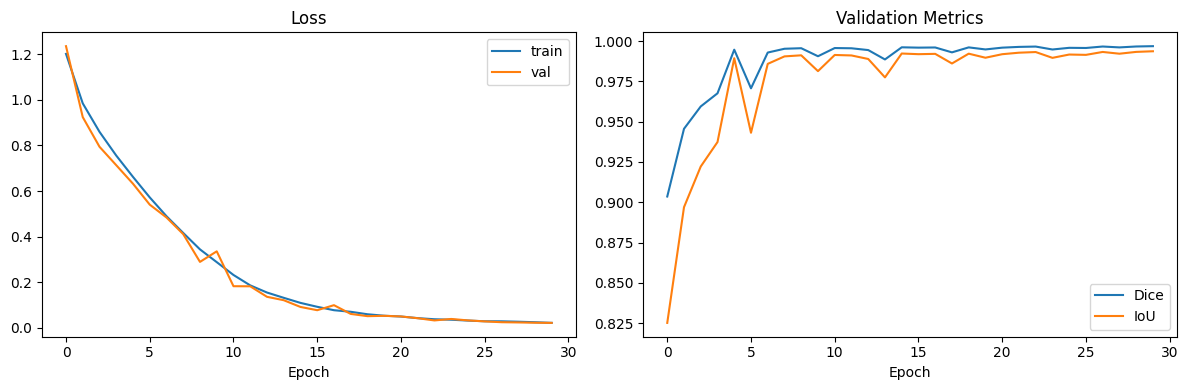

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_dice'], label='Dice')
axes[1].plot(history['val_iou'], label='IoU')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('task3_training_curves.png', dpi=150)
plt.show()

### Visualize predictions on validation images

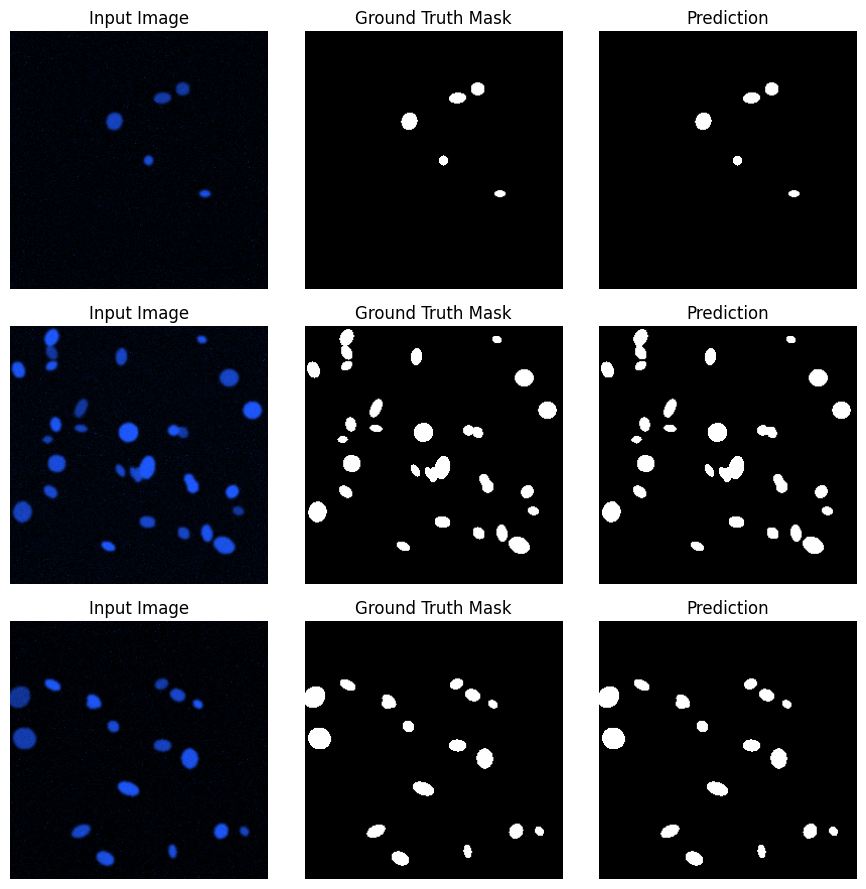

In [ ]:
model.eval()
n_show = 3

fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))

with torch.no_grad():
    for i in range(n_show):
        img, mask = val_ds[i]
        img_batch = img.unsqueeze(0).to(device)
        pred = model(img_batch)
        pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()

        img_display = img.permute(1, 2, 0).numpy()

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title('Input Image')
        axes[i, 1].imshow(mask.squeeze().numpy(), cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title('Prediction')

        for ax in axes[i]:
            ax.axis('off')

plt.tight_layout()
plt.savefig('task3_predictions.png', dpi=150)
plt.show()

##**Task 4: Hybrid pipeline**

In [ ]:
import json
import re

def run_hybrid_pipeline(img_path, model, device):
    fname = os.path.basename(img_path)

    # Load image
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = T.Compose([T.Resize((256,256)), T.ToTensor()])(img_pil).unsqueeze(0).to(device)

    # U-Net prediction
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor)
        pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()

    # regionprops on predicted mask
    labeled = measure.label(pred_mask.astype(int))
    n_objects = int(labeled.max())

    if n_objects > 0:
        img_gray_np = np.array(img_pil.convert('L').resize((256,256))) / 255.0
        props = measure.regionprops_table(
            labeled, intensity_image=img_gray_np,
            properties=['area', 'eccentricity', 'solidity', 'mean_intensity']
        )
        df_props = pd.DataFrame(props)
        mean_area = float(df_props['area'].mean())
        mean_ecc = float(df_props['eccentricity'].mean())
        mean_solidity = float(df_props['solidity'].mean())
    else:
        mean_area = mean_ecc = mean_solidity = 0.0

    # Build prompt for LLM (numbers-only, same style as Task 2)
    prompt = f"""Quantitative summary of a U-Net-segmented microscopy image (image_id: {fname}). No image provided — base interpretation only on these numbers.

Number of objects detected: {n_objects}
Mean object area (pixels): {mean_area:.1f}
Mean eccentricity: {mean_ecc:.2f}
Mean solidity: {mean_solidity:.2f}

For density_class, choose exactly ONE of these words: sparse, moderate, dense, or uncertain. Do not use any other value.
For quality_flag, write "none" if there is no concern, otherwise a brief concern in a few words.

Respond ONLY with a valid JSON object, no extra text, following this example format exactly:
{{"image_id": "example.png", "n_objects": 10, "mean_area": 200.0, "density_class": "moderate", "quality_flag": "none"}}

Now generate the JSON for the actual data given above."""

    llm_response = ollama.chat(model='llava', messages=[{'role': 'user', 'content': prompt}])
    llm_text = llm_response['message']['content']

    # Try to parse JSON out of response (models sometimes wrap in markdown fences)
    try:
        match = re.search(r'\{.*\}', llm_text, re.DOTALL)
        json_str = match.group(0) if match else llm_text
        json_str = json_str.replace('\\_', '_')  # fix llava's markdown-escaped underscores
        parsed = json.loads(json_str.strip())
    except Exception as e:
        parsed = {"image_id": fname, "n_objects": n_objects, "mean_area": mean_area,
                  "density_class": "uncertain", "quality_flag": f"json_parse_failed: {e}"}

    # Narrative paragraph (separate LLM call)
    narrative_prompt = f"""Based on this structured summary of a segmented microscopy image, write ONE short plain-language paragraph (2-3 sentences) describing what was found. Be factual and avoid clinical/diagnostic claims.

{json.dumps(parsed)}"""
    narrative_response = ollama.chat(model='llava', messages=[{'role': 'user', 'content': narrative_prompt}])
    narrative_text = narrative_response['message']['content']

    # normalize/validate density_class as a safety net
    valid_classes = {'sparse', 'moderate', 'dense', 'uncertain'}
    if parsed.get('density_class') not in valid_classes:
        # fallback: simple rule-based classification from n_objects
        if n_objects < 10:
            parsed['density_class'] = 'sparse'
        elif n_objects < 25:
            parsed['density_class'] = 'moderate'
        else:
            parsed['density_class'] = 'dense'
        parsed['quality_flag'] = 'llm_output_invalid_used_fallback'

    return parsed, narrative_text, pred_mask

In [ ]:
test_img_dir = os.path.join(base, 'test', 'images')
test_files = sorted(glob.glob(os.path.join(test_img_dir, '*.png')))

all_records = []
all_narratives = {}

for path in test_files:
    print(f"Processing {os.path.basename(path)}...")
    parsed, narrative, pred_mask = run_hybrid_pipeline(path, model, device)
    all_records.append(parsed)
    all_narratives[parsed.get('image_id', os.path.basename(path))] = narrative

print(f"\nProcessed {len(all_records)} test images.")

Processing test_000.png...
Processing test_001.png...
Processing test_002.png...
Processing test_003.png...
Processing test_004.png...
Processing test_005.png...
Processing test_006.png...
Processing test_007.png...
Processing test_008.png...
Processing test_009.png...
Processing test_010.png...
Processing test_011.png...

Processed 12 test images.


### Aggregate into CSV

In [ ]:
results_df = pd.DataFrame(all_records)
results_df['narrative'] = results_df['image_id'].map(all_narratives)
results_df.to_csv('task4_results.csv', index=False)
print(results_df)

        image_id  n_objects  mean_area density_class quality_flag  \
0   test_000.png          8      191.2         dense         none   
1   test_001.png         14      200.5         dense         none   
2   test_002.png         26      219.7      moderate         none   
3   test_003.png         19      203.9         dense         none   
4   test_004.png         43      328.7         dense         none   
5   test_005.png         16      406.9         dense         none   
6   test_006.png          8      198.0      moderate         none   
7   test_007.png         23      205.7      moderate         none   
8   test_008.png         23      239.8      moderate         none   
9   test_009.png         21      178.9         dense         none   
10  test_010.png         39      335.1      moderate         none   
11  test_011.png         20      184.0         dense         none   

                                            narrative  
0    The image shows a group of 8 objects with

##**Extension**

### Check what corruptions exist

In [ ]:
corrupted_dir = os.path.join(base, 'test_corrupted', 'images')
corrupted_files = sorted(glob.glob(os.path.join(corrupted_dir, '*.png')))
print(f"Found {len(corrupted_files)} corrupted images:")
for f in corrupted_files:
    print(" ", os.path.basename(f))

Found 4 corrupted images:
  test_000_blur.png
  test_000_lowcontrast.png
  test_004_blur.png
  test_004_lowcontrast.png


### Run the pipeline on corrupted images + compare to clean baseline

In [ ]:
robustness_records = []

for corrupted_path in corrupted_files:
    fname = os.path.basename(corrupted_path)
    # extract source image id and corruption type from filename, e.g. test_000_blur.png
    parts = fname.replace('.png', '').split('_')
    source_id = f"{parts[0]}_{parts[1]}.png"
    corruption_type = '_'.join(parts[2:])

    parsed, narrative, pred_mask = run_hybrid_pipeline(corrupted_path, model, device)
    parsed['source_image'] = source_id
    parsed['corruption_type'] = corruption_type
    parsed['narrative'] = narrative
    robustness_records.append(parsed)

    print(f"{fname}: n_objects={parsed['n_objects']}, density={parsed['density_class']}")

robustness_df = pd.DataFrame(robustness_records)
print(robustness_df)

test_000_blur.png: n_objects=7, density=moderate
test_000_lowcontrast.png: n_objects=0, density=sparse
test_004_blur.png: n_objects=10, density=dense
test_004_lowcontrast.png: n_objects=0, density=uncertain
                   image_id  n_objects  mean_area density_class  \
0         test_000_blur.png          7      426.0      moderate   
1  test_000_lowcontrast.png          0        0.0        sparse   
2         test_004_blur.png         10     2791.4         dense   
3  test_004_lowcontrast.png          0        0.0     uncertain   

                       quality_flag  source_image corruption_type  \
0                              none  test_000.png            blur   
1  llm_output_invalid_used_fallback  test_000.png     lowcontrast   
2                              none  test_004.png            blur   
3                              none  test_004.png     lowcontrast   

                                           narrative  
0   The segmented microscopy image shows seven ob...  
1

### Compare against clean baseline numbers

In [ ]:
# pull the matching clean-image rows from your Task 4 results for direct comparison
comparison_rows = []
for _, row in robustness_df.iterrows():
    clean_row = results_df[results_df['image_id'] == row['source_image']]
    if not clean_row.empty:
        clean_n = clean_row.iloc[0]['n_objects']
        clean_area = clean_row.iloc[0]['mean_area']
        clean_density = clean_row.iloc[0]['density_class']
        comparison_rows.append({
            'source_image': row['source_image'],
            'corruption_type': row['corruption_type'],
            'clean_n_objects': clean_n,
            'corrupted_n_objects': row['n_objects'],
            'clean_mean_area': clean_area,
            'corrupted_mean_area': row['mean_area'],
            'clean_density': clean_density,
            'corrupted_density': row['density_class'],
        })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)
comparison_df.to_csv('robustness_comparison.csv', index=False)

   source_image corruption_type  clean_n_objects  corrupted_n_objects  \
0  test_000.png            blur                8                    7   
1  test_000.png     lowcontrast                8                    0   
2  test_004.png            blur               43                   10   
3  test_004.png     lowcontrast               43                    0   

   clean_mean_area  corrupted_mean_area clean_density corrupted_density  
0            191.2                426.0         dense          moderate  
1            191.2                  0.0         dense            sparse  
2            328.7               2791.4         dense             dense  
3            328.7                  0.0         dense         uncertain  


### Visual side-by-side (clean vs corrupted, mask overlay)

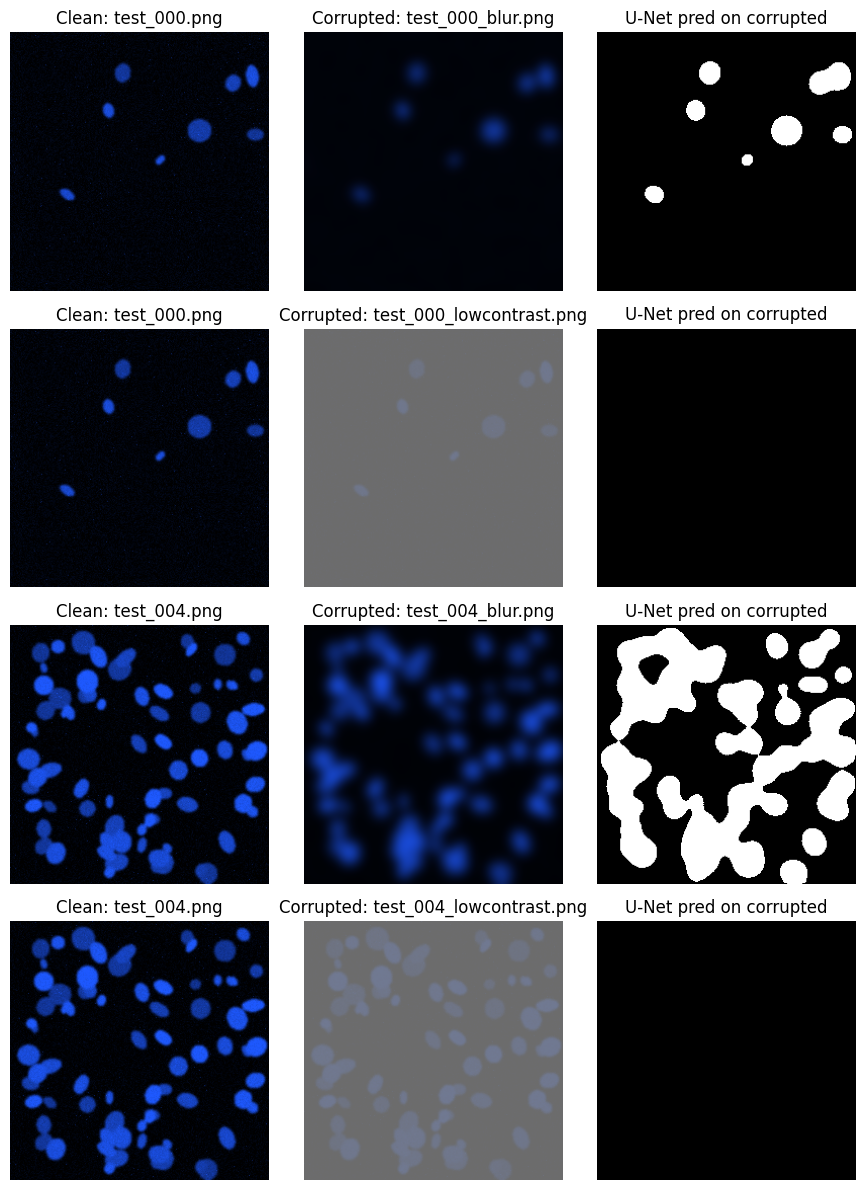

In [ ]:
fig, axes = plt.subplots(len(corrupted_files), 3, figsize=(9, 3*len(corrupted_files)))

for i, corrupted_path in enumerate(corrupted_files):
    fname = os.path.basename(corrupted_path)
    parts = fname.replace('.png', '').split('_')
    source_id = f"{parts[0]}_{parts[1]}.png"
    clean_path = os.path.join(test_img_dir, source_id)

    clean_img = Image.open(clean_path).convert('RGB').resize((256,256))
    corrupt_img = Image.open(corrupted_path).convert('RGB').resize((256,256))

    _, _, corrupt_mask = run_hybrid_pipeline(corrupted_path, model, device)

    axes[i,0].imshow(clean_img); axes[i,0].set_title(f'Clean: {source_id}')
    axes[i,1].imshow(corrupt_img); axes[i,1].set_title(f'Corrupted: {fname}')
    axes[i,2].imshow(corrupt_mask, cmap='gray'); axes[i,2].set_title('U-Net pred on corrupted')
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('robustness_visual.png', dpi=150)
plt.show()